# How the patient-level 3-D scores are obtained (DSC & NSD)

Our segmenter (SAM3) is a **2-D** model — it sees one slice at a time. A patient's CT is a **3-D stack** of slices. To get a *patient-level* score we:

1. run the trained 2-D model on **every slice** of a test patient's volume,
2. **stack** the per-slice masks back into a 3-D volume, and
3. compare that assembled 3-D mask to the 3-D ground truth.

No new training — the **same** trained 2-D model, just applied across a whole volume.

### The two metrics
- **DSC — Dice Similarity Coefficient** = `2·|overlap| / (|pred| + |GT|)`. Measures **volume overlap** (this is exactly the 'Dice' number we've been reporting).
- **NSD — Normalized Surface Distance** (surface Dice) = the fraction of the two masks' **surfaces** that lie within a tolerance **τ mm** of each other. Measures **boundary agreement** — a blob can overlap well (high DSC) but still have a ragged edge (lower NSD), so NSD is the stricter, boundary-focused check.

*(These are semi-oracle numbers — each slice is prompted with a ground-truth-derived box — so they are the interactive ceiling, not the autonomous number.)*


## Setup — load the trained model


In [1]:
import sys, json, glob, numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, '/home/ud3d4/Desktop/SWOG/src/scripts')
from eval_ausam_3d import hu_rgb, nsd, load_msd, WIN, MINPX
from run_pancreas_sam3 import bbox_from_mask, extract_best_mask_soft, _load_sam3_ckpt, SAM3_MODEL_ID, HF_TOKEN
from skimage.transform import resize
from torch.amp import autocast
from transformers import Sam3Processor
ROOT='/home/ud3d4/Desktop/SWOG'; POOL='/scratch/ud3d4/acm_data/organ_pool_lkp'; DEV='cuda:0'
proc = Sam3Processor.from_pretrained(SAM3_MODEL_ID, token=HF_TOKEN)
model = _load_sam3_ckpt(f'{POOL}/sam3_organ_generic_ausam_msd.pth', DEV)   # the MSD organ AUSAM model
print('loaded MSD organ AUSAM (2-D) model')


/home/ud3d4/.conda/envs/llmft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


I0000 00:00:1786052347.115691 3325518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786052347.153841 3325518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch 2.5.1+cu121, GPUs: 2


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 18847.05it/s]


/home/ud3d4/Desktop/SWOG/src/scripts/run_pancreas_sam3.py:963: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


loaded MSD organ AUSAM (2-D) model


## Step 1 — pick a held-out test volume
We use MSD case `pancreas_019` (a test patient). Note the **spacing** (mm per voxel) — NSD needs it, and it converts voxel counts to cm³.


In [2]:
case, organ, LABEL = 'pancreas_019', 'pancreas', 1   # MSD: pancreas = label 1
ct, lbl, spacing = load_msd(case)
gt3d = (lbl == LABEL)
print(f'volume {case}: shape {ct.shape}, spacing {spacing} mm')
print(f'GT pancreas: {int(gt3d.sum())} voxels on {int((gt3d.any(axis=(0,1))).sum())} slices')


volume pancreas_019: shape (512, 512, 85), spacing [0.8789060115814209, 0.8789060115814209, 2.5] mm
GT pancreas: 47794 voxels on 30 slices


## Step 2 — run the 2-D model on every pancreas-present slice
For each slice: HU-window to RGB (matching training), resize to 256², prompt SAM3 with the organ word + the GT-derived box, take the mask, resize back to the slice's native size. We keep a few example slices to show.


In [3]:
def predict_slice(rgb, organ, box):
    inp = proc(images=[rgb], text=[organ], input_boxes=[[box]], input_boxes_labels=[[1]], return_tensors='pt')
    kw = {'pixel_values': inp['pixel_values'].to(DEV)}
    for k in ('input_ids','attention_mask','input_boxes','input_boxes_labels'):
        if inp.get(k) is not None: kw[k] = inp[k].to(DEV)
    with torch.no_grad(), autocast('cuda'):
        out = model(**kw); pm = extract_best_mask_soft(out.pred_masks, out.pred_logits)
        pm = torch.nn.functional.interpolate(pm.float(), size=(256,256), mode='bilinear', align_corners=False)
    return pm.sigmoid().squeeze().cpu().numpy() > 0.5

pred3d = np.zeros(ct.shape, np.uint8); examples = []
for z in range(ct.shape[2]):
    gm256 = resize((lbl[:,:,z]==LABEL).astype(float), (256,256), order=0, preserve_range=True) > 0.5
    if gm256.sum() < MINPX: continue                       # no pancreas on this slice -> stays background
    rgb = hu_rgb(resize(ct[:,:,z], (256,256), preserve_range=True, anti_aliasing=True))
    box = bbox_from_mask(gm256.astype(np.uint8), pad=3)
    pr256 = predict_slice(rgb, organ, box if box is not None else [0,0,255,255])
    pred3d[:,:,z] = resize(pr256.astype(float), ct[:,:,z].shape, order=0, preserve_range=True) > 0.5
    examples.append((z, rgb, gm256, pr256))
print(f'ran the 2-D model on {len(examples)} pancreas-present slices')


ran the 2-D model on 30 pancreas-present slices


A few of those slices — green = ground truth, red = the 2-D model's prediction:


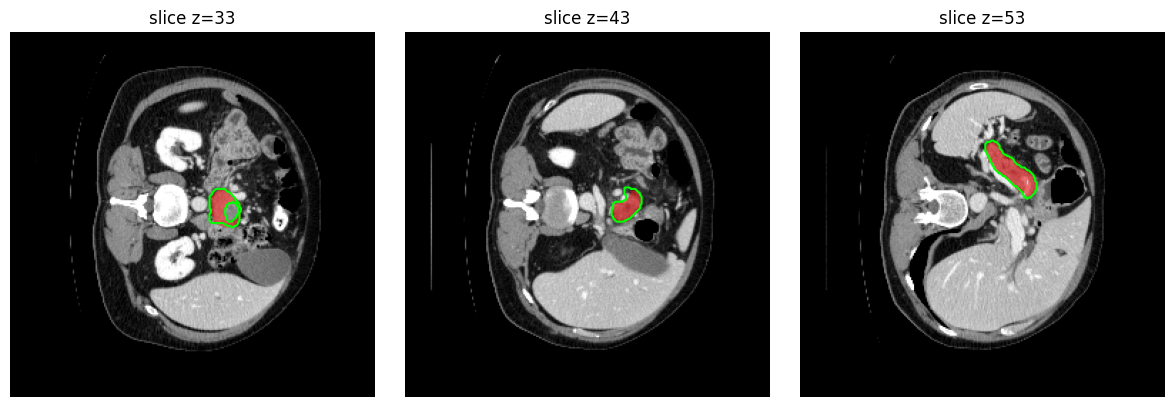

In [4]:
sel = examples[len(examples)//5 :: max(1, len(examples)//3)][:3]
fig, ax = plt.subplots(1, len(sel), figsize=(4*len(sel), 4))
if len(sel)==1: ax=[ax]
for a,(z,rgb,gm,pr) in zip(ax, sel):
    a.imshow(rgb[...,0], cmap='gray')
    a.contour(gm.astype(float), [0.5], colors='lime', linewidths=1.5)
    if pr.any(): a.imshow(np.ma.masked_where(~pr, pr.astype(float)), cmap='autumn', alpha=0.5)
    a.set_title(f'slice z={z}'); a.axis('off')
plt.tight_layout(); plt.show()


## Step 3 — assemble the 3-D mask and score
Now we have a full 3-D prediction. Compute **DSC** (volume overlap) and **NSD** (surface agreement, τ = 1 & 2 mm), and the predicted vs GT **volume in cm³** (using the spacing).


In [5]:
def dice(p,g): s=int(p.sum())+int(g.sum()); return 2*int((p&g).sum())/s if s else 1.0
d = dice(pred3d.astype(bool), gt3d); nv = nsd(pred3d.astype(bool), gt3d, spacing)
vox_cm3 = spacing[0]*spacing[1]*spacing[2] / 1000
print(f'DSC (Dice, volume overlap) = {d:.3f}')
print(f'NSD @1mm / @2mm (surface)  = {nv["1.0mm"]:.3f} / {nv["2.0mm"]:.3f}')
print(f'predicted volume           = {int(pred3d.sum())*vox_cm3:6.1f} cc')
print(f'ground-truth volume        = {int(gt3d.sum())*vox_cm3:6.1f} cc')


DSC (Dice, volume overlap) = 0.907
NSD @1mm / @2mm (surface)  = 0.751 / 0.880
predicted volume           =   90.9 cc
ground-truth volume        =   92.3 cc


The assembled 3-D masks, seen as coronal max-projections (GT vs prediction):


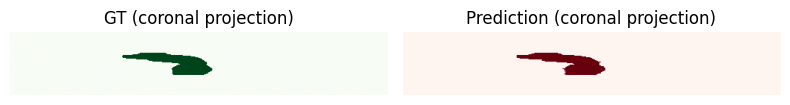

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(gt3d.max(axis=1).T[::-1], cmap='Greens'); ax[0].set_title('GT (coronal projection)')
ax[1].imshow(pred3d.max(axis=1).T[::-1], cmap='Reds');  ax[1].set_title('Prediction (coronal projection)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()


### Reading the two numbers
For this case, **DSC ≈ 0.91** (the volumes overlap well) while **NSD@1mm** is lower and **NSD@2mm** is in between — the boundary is close but not pixel-perfect, which is exactly what NSD is designed to expose. That's why challenges report **both**: DSC for bulk overlap, NSD for edge quality.


## Aggregate — DSC & NSD across all held-out test patients
Computed the same way over every test patient (`eval_ausam_3d.py`). NSD needs mm spacing, so LiTS (`.npy` volumes, no spacing) shows DSC only.


In [7]:
import pandas as pd
name = {'msd':'MSD (pancreas)','flare_task2':'FLARE-Task2','lits':'LiTS','flare23':'FLARE23'}
rows = []
for f in sorted(glob.glob(f'{ROOT}/results/ausam_3d_*.json')):
    if 'summary' in f: continue
    d = json.load(open(f)); ds = d['dataset']
    for o, dsc in d['mean_3d_dice'].items():
        nv = d.get('mean_nsd_2mm', {}).get(o)
        rows.append([name.get(ds,ds), o, f'{dsc*100:.1f}%', (f'{nv*100:.1f}%' if nv else 'n/a'), d['n_patients']])
pd.DataFrame(rows, columns=['Dataset','Organ','DSC (Dice)','NSD @2mm','# test patients'])


,Dataset,Organ,DSC (Dice),NSD @2mm,# test patients
0,FLARE23,liver,97.1%,92.5%,10
1,FLARE23,kidney,95.4%,90.8%,10
2,FLARE23,pancreas,88.4%,86.9%,10
3,FLARE-Task2,liver,98.1%,94.7%,20
4,FLARE-Task2,kidney,96.4%,94.6%,20
5,FLARE-Task2,pancreas,91.6%,91.9%,20
6,LiTS,liver,95.5%,n/a,6
7,MSD (pancreas),pancreas,88.1%,84.8%,33


## Takeaways
- **DSC = the Dice we already had** (volume overlap); **NSD** adds the boundary-quality view.
- The patient-level numbers come from the **same 2-D models**, applied slice-by-slice and stacked — not a different model.
- These are **semi-oracle** (GT box per slice) → the *interactive ceiling* in 3-D. The autonomous number (no box) is a separate, later evaluation.
- LiTS lacks spacing (`.npy`), so NSD isn't available there; MSD/FLARE-Task2/FLARE23 have full DSC + NSD.
